In [ ]:
# =========================================================
# INSTALL LIBRARY
# =========================================================

!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install ucimlrepo

In [ ]:
# =========================================================
# IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import (
    load_iris,
    load_breast_cancer,
    load_wine
)

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from matplotlib.colors import ListedColormap

In [ ]:
# =========================================================
# LOAD DATASET
# =========================================================

# ---------------- IRIS ----------------
iris = load_iris()

X_iris = iris.data
y_iris = iris.target

# ---------------- BREAST CANCER ----------------
cancer = load_breast_cancer()

X_cancer = cancer.data
y_cancer = cancer.target

# ---------------- WINE ----------------
wine = load_wine()

X_wine = wine.data
y_wine = wine.target

# ---------------- HEART DISEASE ----------------
heart = fetch_ucirepo(id=45)

X_heart = heart.data.features
y_heart = heart.data.targets

# Ubah target jadi 1 dimensi
y_heart = y_heart.values.ravel()

# =====================================================
# HANDLE MISSING VALUE
# =====================================================

# Isi NaN dengan mean tiap kolom
X_heart = X_heart.fillna(X_heart.mean())

# Kalau target ada NaN juga
y_heart = pd.Series(y_heart).fillna(0)


In [ ]:
# =========================================================
# FUNCTION SVM EXPERIMENT
# =========================================================

def svm_experiment(X, y, dataset_name):

    print("\n")
    print("=" * 70)
    print(f"DATASET : {dataset_name}")
    print("=" * 70)

    # =====================================================
    # SPLIT DATA
    # =====================================================

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # =====================================================
    # STANDARDIZATION
    # =====================================================

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # =====================================================
    # COMPARE KERNEL
    # =====================================================

    print("\nCOMPARE SVM KERNEL")

    kernels = ['linear', 'rbf', 'poly', 'sigmoid']

    for kernel in kernels:

        model = SVC(
            kernel=kernel,
            C=1,
            gamma='scale'
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        print("-" * 50)
        print(f"Kernel   : {kernel}")
        print(f"Accuracy : {accuracy:.4f}")

    # =====================================================
    # GRID SEARCH
    # =====================================================

    print("\nGRID SEARCH HYPERPARAMETER TUNING")

    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': [1, 0.1, 0.01, 0.001],
        'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
    }

    grid = GridSearchCV(
        SVC(),
        param_grid,
        refit=True,
        verbose=1,
        cv=5
    )

    grid.fit(X_train, y_train)

    # =====================================================
    # BEST MODEL
    # =====================================================

    best_model = grid.best_estimator_

    print("\nBEST PARAMETER")
    print(grid.best_params_)

    # =====================================================
    # PREDICTION
    # =====================================================

    y_pred = best_model.predict(X_test)

    # =====================================================
    # EVALUATION
    # =====================================================

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    print("\nEVALUATION RESULT")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\nCLASSIFICATION REPORT")
    print(classification_report(y_test, y_pred))

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_test, y_pred)

    print("\nCONFUSION MATRIX")
    print(cm)

    # =====================================================
    # FALSE POSITIVE & FALSE NEGATIVE
    # =====================================================

    if cm.shape == (2, 2):

        TN, FP, FN, TP = cm.ravel()

        print(f"\nFalse Positive (Error-1): {FP}")
        print(f"False Negative (Error-2): {FN}")

    # =====================================================
    # DECISION BOUNDARY
    # =====================================================

    print("\nSHOW DECISION BOUNDARY")

    X_visual = np.array(X)[:, :2]

    X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
        X_visual,
        y,
        test_size=0.2,
        random_state=42
    )

    scaler_vis = StandardScaler()

    X_train_vis = scaler_vis.fit_transform(X_train_vis)

    model_vis = SVC(
        kernel=grid.best_params_['kernel']
    )

    model_vis.fit(X_train_vis, y_train_vis)

    x_min, x_max = X_train_vis[:, 0].min() - 1, X_train_vis[:, 0].max() + 1
    y_min, y_max = X_train_vis[:, 1].min() - 1, X_train_vis[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model_vis.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(xx, yy, Z, alpha=0.4)

    plt.scatter(
        X_train_vis[:, 0],
        X_train_vis[:, 1],
        c=y_train_vis,
        edgecolors='k'
    )

    plt.title(
        f"{dataset_name} - Decision Boundary ({grid.best_params_['kernel']})"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.show()



DATASET : IRIS

COMPARE SVM KERNEL
--------------------------------------------------
Kernel   : linear
Accuracy : 1.0000
--------------------------------------------------
Kernel   : rbf
Accuracy : 0.9667
--------------------------------------------------
Kernel   : poly
Accuracy : 0.9000
--------------------------------------------------
Kernel   : sigmoid
Accuracy : 0.9000

GRID SEARCH HYPERPARAMETER TUNING
Fitting 5 folds for each of 64 candidates, totalling 320 fits

BEST PARAMETER
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

EVALUATION RESULT
Accuracy  : 0.9667
Precision : 0.9697
Recall    : 0.9667
F1-Score  : 0.9666

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.9

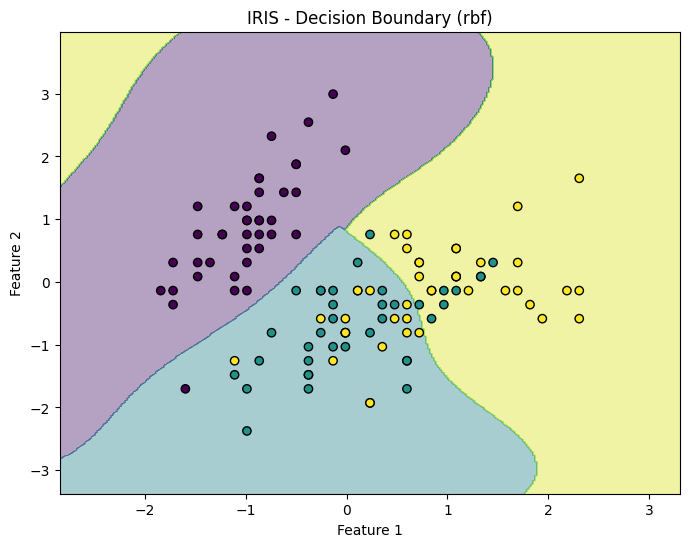



DATASET : BREAST CANCER

COMPARE SVM KERNEL
--------------------------------------------------
Kernel   : linear
Accuracy : 0.9737
--------------------------------------------------
Kernel   : rbf
Accuracy : 0.9825
--------------------------------------------------
Kernel   : poly
Accuracy : 0.9123
--------------------------------------------------
Kernel   : sigmoid
Accuracy : 0.9298

GRID SEARCH HYPERPARAMETER TUNING
Fitting 5 folds for each of 64 candidates, totalling 320 fits

BEST PARAMETER
{'C': 0.1, 'gamma': 1, 'kernel': 'linear'}

EVALUATION RESULT
Accuracy  : 0.9825
Precision : 0.9825
Recall    : 0.9825
F1-Score  : 0.9825

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


CONFUSIO

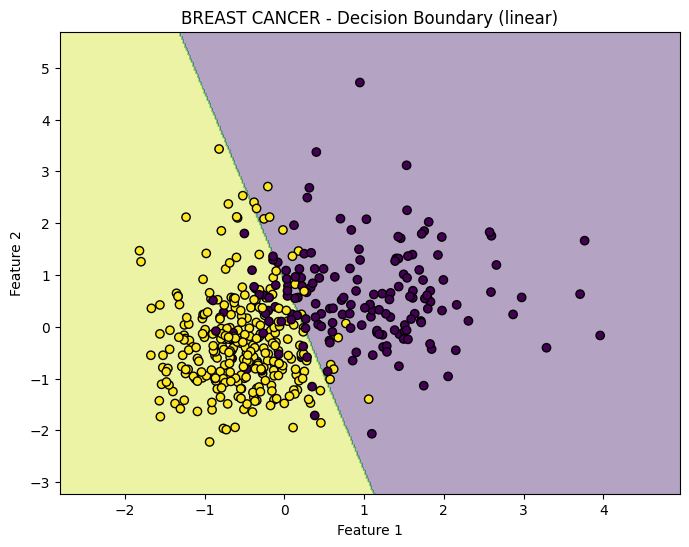



DATASET : WINE

COMPARE SVM KERNEL
--------------------------------------------------
Kernel   : linear
Accuracy : 0.9444
--------------------------------------------------
Kernel   : rbf
Accuracy : 0.9722
--------------------------------------------------
Kernel   : poly
Accuracy : 0.9444
--------------------------------------------------
Kernel   : sigmoid
Accuracy : 1.0000

GRID SEARCH HYPERPARAMETER TUNING
Fitting 5 folds for each of 64 candidates, totalling 320 fits

BEST PARAMETER
{'C': 0.1, 'gamma': 1, 'kernel': 'linear'}

EVALUATION RESULT
Accuracy  : 0.9722
Precision : 0.9741
Recall    : 0.9722
F1-Score  : 0.9720

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       

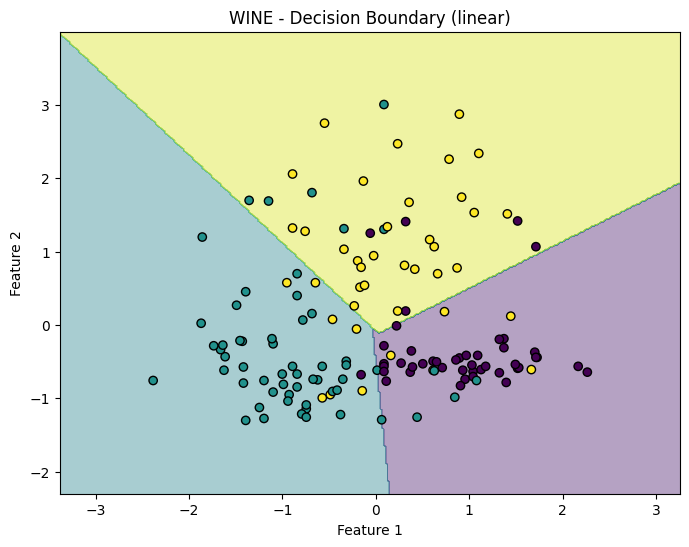



DATASET : HEART DISEASE

COMPARE SVM KERNEL
--------------------------------------------------
Kernel   : linear
Accuracy : 0.5902
--------------------------------------------------
Kernel   : rbf
Accuracy : 0.5410
--------------------------------------------------
Kernel   : poly
Accuracy : 0.5410
--------------------------------------------------
Kernel   : sigmoid
Accuracy : 0.6066

GRID SEARCH HYPERPARAMETER TUNING
Fitting 5 folds for each of 64 candidates, totalling 320 fits

BEST PARAMETER
{'C': 1, 'gamma': 0.1, 'kernel': 'sigmoid'}

EVALUATION RESULT
Accuracy  : 0.6230
Precision : 0.5668
Recall    : 0.6230
F1-Score  : 0.5838

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.78      0.94      0.85        33
           1       0.50      0.27      0.35        11
           2       0.17      0.14      0.15         7
           3       0.33      0.43      0.38         7
           4       0.00      0.00      0.00         3

    accur

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


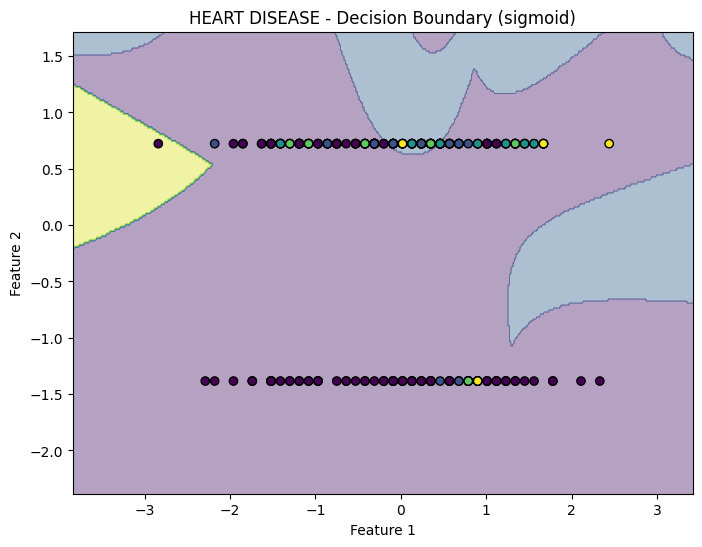

In [ ]:
# =========================================================
# RUN EXPERIMENT
# =========================================================

# ---------------- IRIS ----------------
svm_experiment(
    X_iris,
    y_iris,
    "IRIS"
)

# ---------------- BREAST CANCER ----------------
svm_experiment(
    X_cancer,
    y_cancer,
    "BREAST CANCER"
)

# ---------------- WINE ----------------
svm_experiment(
    X_wine,
    y_wine,
    "WINE"
)

# ---------------- HEART DISEASE ----------------
svm_experiment(
    X_heart,
    y_heart,
    "HEART DISEASE"
)